# NB10 — Explanation Stability (CDTS Component c)

**The competence-coupled hypothesis (the unifying test, paper §8):**
Does explanation FAITHFULNESS degrade with competence, like calibration (a) and like the
label-free signals (d)? If YES -> competence is confirmed as the organizing principle of
detector trustworthiness across THREE independent trust signals.

**Method:** Grad-CAM (hooked at conv4, the 2048x8x8 spatial feature map of the DeepfakeBench
Xception) + deletion/insertion AUDC faithfulness. Across generators spanning the competence
range, test whether faithfulness correlates with AUC.

**Faithfulness (deletion/insertion AUDC):**
- DELETION: remove most-important pixels progressively; faithful explanation -> prob_fake drops
  fast -> low deletion-AUC.
- INSERTION: add most-important pixels to a blurred base; faithful -> prob_fake rises fast ->
  high insertion-AUC.
- Faithfulness = insertion_AUC - deletion_AUC (higher = more faithful).

**Stability under degradation (secondary):** Kendall-tau between clean and noise/blur-degraded
Grad-CAM maps. Does explanation stability also track competence?

Extends Gowrisankar & Thing (2024) by tying explanation faithfulness to the trust score and to
competence.


## Cell 1 — Setup + load FS Xception (inference env)

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
PARENT = "/content/drive/MyDrive/CDTS_Research"
DFB = f"{REPO}/external/DeepfakeBench"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"{PARENT}/{f}"): subprocess.run(f'cp "{PARENT}/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)

import importlib.util
for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path = [p for p in sys.path if p not in (f"{DFB}/training", f"{REPO}/src", DFB)]
sys.path.insert(0, DFB); sys.path.insert(0, f"{DFB}/training"); sys.path.append(f"{REPO}/src")
spec = importlib.util.spec_from_file_location("inference", f"{REPO}/src/inference.py")
inference = importlib.util.module_from_spec(spec); sys.modules["inference"]=inference
spec.loader.exec_module(inference)
model, device, info = inference.load_detector(dfb_root=DFB, backbone_name="xception",
    ckpt_path=f"{REPO}/weights/train_on_fs/xception.pth")
model.eval()
print("FS Xception load:", info, "device:", device)

Mounted at /content/drive
FS Xception load: {'missing': 0, 'unexpected': 0} device: cuda


## Cell 2 — Grad-CAM + faithfulness machinery (hooked at conv4)

Grad-CAM at conv4 (2048x8x8). Preprocessing matches the detector: RGB, resize 256, normalize
mean=std=0.5. Deletion/insertion use the model's prob over masked images.


In [2]:
import torch, numpy as np
import torch.nn.functional as F
import cv2
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"

MEAN = torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)
STD  = torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)

def load_img(path):
    im = cv2.imread(path)[:,:,::-1]  # BGR->RGB
    im = cv2.resize(im, (256,256), interpolation=cv2.INTER_LINEAR)
    return im.astype(np.float32)/255.0  # HWC [0,1]

def to_tensor(im_hwc):
    t = torch.from_numpy(im_hwc).permute(2,0,1).unsqueeze(0).to(device)
    return (t - MEAN)/STD

bb = model.backbone
target_layer = dict(bb.named_modules())['conv4']

def grad_cam(im_hwc):
    acts={}; grads={}
    def fh(m,i,o): acts['a']=o
    def bh(m,gi,go): grads['g']=go[0]
    h1=target_layer.register_forward_hook(fh); h2=target_layer.register_full_backward_hook(bh)
    x = to_tensor(im_hwc).requires_grad_(True)
    out = model({'image':x}, inference=False)
    score = out['cls'][0,1]  # fake logit
    model.zero_grad(); score.backward()
    A = acts['a'][0]; G = grads['g'][0]               # (2048,8,8)
    w = G.mean(dim=(1,2))                               # GAP of grads -> (2048,)
    cam = F.relu((w.view(-1,1,1)*A).sum(0))            # (8,8)
    cam = cam - cam.min(); cam = cam/(cam.max()+1e-8)
    cam = F.interpolate(cam.view(1,1,8,8),size=(256,256),mode='bilinear',align_corners=False)[0,0]
    h1.remove(); h2.remove()
    return cam.detach().cpu().numpy(), float(torch.sigmoid(out['cls'][0,1]-out['cls'][0,0]).detach())

@torch.no_grad()
def prob_fake_of(im_hwc):
    out = model({'image':to_tensor(im_hwc)}, inference=True)
    return float(out['prob']) if out['prob'].dim()==0 else float(out['prob'][0])

def deletion_insertion_auc(im_hwc, cam, steps=20):
    # order pixels by importance
    flat = cam.flatten(); order = np.argsort(-flat)  # most important first
    n = len(order); chunk = n//steps
    H,W = cam.shape
    blurred = cv2.GaussianBlur(im_hwc,(0,0),sigmaX=11)
    # DELETION: start full image, progressively replace important pixels with blurred
    img_del = im_hwc.copy(); del_scores=[prob_fake_of(img_del)]
    # INSERTION: start blurred, progressively reveal important pixels
    img_ins = blurred.copy(); ins_scores=[prob_fake_of(img_ins)]
    for s in range(steps):
        idx = order[s*chunk:(s+1)*chunk]
        ys,xs = np.unravel_index(idx,(H,W))
        img_del[ys,xs,:] = blurred[ys,xs,:]; del_scores.append(prob_fake_of(img_del))
        img_ins[ys,xs,:] = im_hwc[ys,xs,:];  ins_scores.append(prob_fake_of(img_ins))
    del_auc = np.trapz(del_scores)/len(del_scores)
    ins_auc = np.trapz(ins_scores)/len(ins_scores)
    return ins_auc, del_auc, ins_auc-del_auc

print("Grad-CAM + faithfulness machinery ready (hooked at conv4)")

Grad-CAM + faithfulness machinery ready (hooked at conv4)


## Cell 3 — Faithfulness vs competence across generators

Sample N frames per generator (fakes, where the explanation should highlight manipulation),
across generators spanning the competence range. Compute mean faithfulness per generator.
Need the actual frames -> use the saved score parquets to get frame_paths (local /content
frames are gone, but the parquet stored frame_path pointing to Drive Celeb-DF reals AND the
unzipped fakes which are deleted). So we RE-USE the manifest frame_paths that still resolve:
the Celeb-DF reals persist on Drive; for fakes we need to re-unzip. To keep this tractable,
we score faithfulness on a SAMPLE and re-unzip only the needed methods.


In [3]:
import pandas as pd, numpy as np, os, glob, zipfile, shutil, random
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT = "/content/drive/MyDrive/CDTS_Research/DF40"
LOCALCORE = f"{REPO}/data/df40_core/test"
random.seed(42); np.random.seed(42)

# generators spanning competence range (from timeline): high, mid, low AUC
# (method, era_auc for reference) - pick a spread
SPAN = ["simswap","blendface","ddim","StyleGAN2","lia","DiT","pixart","sadtalker"]
# AUCs: simswap .95, blendface .94, ddim .77, StyleGAN2 .65, lia .61, DiT .52, pixart .43, sadtalker .43

N_FRAMES = 60   # frames per generator for faithfulness (Grad-CAM+del/ins is ~40 fwd passes each)

def get_zip(method):
    for cand in [f"{LOCALCORE}/{method}.zip", f"{SHORTCUT}/{method}.zip"]:
        if os.path.exists(cand) and os.path.getsize(cand)>1e6: return cand
    return None

rows = []
for method in SPAN:
    print(f"=== {method} ===")
    sp = f"{REPO}/reports/scores/xceptionFS_df40_{method}.parquet"
    if not os.path.exists(sp): print("  no scores, skip"); continue
    s = pd.read_parquet(sp)
    fakes = s[s.label==1]
    auc = None
    tl = pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")
    if method in tl.method.values: auc = float(tl[tl.method==method].AUC.iloc[0])

    zp = get_zip(method)
    if zp is None: print("  no zip, skip"); continue
    fdir = f"/content/xai_{method}"
    if not os.path.isdir(fdir):
        os.makedirs(fdir,exist_ok=True)
        try:
            with zipfile.ZipFile(zp) as z: z.extractall(fdir)
        except Exception as e:
            print(f"  unzip fail: {str(e)[:60]}"); shutil.rmtree(fdir,ignore_errors=True); continue
    fake_index = {"/".join(fp.split("/")[-2:]): fp for fp in glob.glob(f"{fdir}/**/*.png",recursive=True)}

    # sample N fake frames that resolve to local files
    sample = fakes.sample(min(len(fakes), N_FRAMES*2), random_state=42)
    faiths=[]
    done=0
    for _, r in sample.iterrows():
        key = "/".join(str(r['frame_path']).split("/")[-2:])
        fp = fake_index.get(key)
        if fp is None or not os.path.exists(fp): continue
        try:
            im = load_img(fp)
            cam,_ = grad_cam(im)
            ins,dele,faith = deletion_insertion_auc(im, cam, steps=20)
            faiths.append(faith)
            done+=1
            if done>=N_FRAMES: break
        except Exception as e:
            continue
    shutil.rmtree(fdir, ignore_errors=True)
    if faiths:
        rows.append({"method":method,"AUC":auc,"n_frames":len(faiths),
                     "faithfulness":float(np.mean(faiths)),"faith_std":float(np.std(faiths))})
        print(f"  AUC={auc}  mean faithfulness={np.mean(faiths):.4f} (n={len(faiths)})")

fa = pd.DataFrame(rows)
fa.to_csv(f"{REPO}/reports/calibration/explanation_faithfulness.csv", index=False)
print("\n=== faithfulness per generator ===")
print(fa.to_string(index=False))

=== simswap ===


/tmp/ipykernel_10741/1778788153.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  del_auc = np.trapz(del_scores)/len(del_scores)
/tmp/ipykernel_10741/1778788153.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ins_auc = np.trapz(ins_scores)/len(ins_scores)


  AUC=0.9478  mean faithfulness=0.0083 (n=60)
=== blendface ===


/tmp/ipykernel_10741/1778788153.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  del_auc = np.trapz(del_scores)/len(del_scores)
/tmp/ipykernel_10741/1778788153.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ins_auc = np.trapz(ins_scores)/len(ins_scores)


  AUC=0.9429  mean faithfulness=0.0063 (n=60)
=== ddim ===


...

  AUC=0.5214  mean faithfulness=0.1513 (n=60)
=== pixart ===


/tmp/ipykernel_10741/1778788153.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  del_auc = np.trapz(del_scores)/len(del_scores)
/tmp/ipykernel_10741/1778788153.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ins_auc = np.trapz(ins_scores)/len(ins_scores)


  AUC=0.4329  mean faithfulness=0.3739 (n=60)
=== sadtalker ===


/tmp/ipykernel_10741/1778788153.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  del_auc = np.trapz(del_scores)/len(del_scores)
/tmp/ipykernel_10741/1778788153.py:59: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ins_auc = np.trapz(ins_scores)/len(ins_scores)


  AUC=0.427  mean faithfulness=0.2984 (n=60)

=== faithfulness per generator ===
   method    AUC  n_frames  faithfulness  faith_std
  simswap 0.9478        60      0.008319   0.020282
blendface 0.9429        60      0.006315   0.018629
     ddim 0.7661        60      0.064613   0.151942
StyleGAN2 0.6491        60      0.178068   0.246746
      lia 0.6068        60      0.179550   0.239948
      DiT 0.5214        60      0.151277   0.231563
   pixart 0.4329        60      0.373911   0.301788
sadtalker 0.4270        60      0.298359   0.294944


## Cell 4 — THE TEST: does explanation faithfulness couple to competence?

In [4]:
import pandas as pd, numpy as np
from scipy.stats import pearsonr, spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
fa = pd.read_csv(f"{REPO}/reports/calibration/explanation_faithfulness.csv")

if len(fa) >= 4 and fa.AUC.notna().sum() >= 4:
    d = fa.dropna(subset=['AUC','faithfulness'])
    r,p = pearsonr(d.AUC, d.faithfulness); rs,ps = spearmanr(d.AUC, d.faithfulness)
    print(f"=== explanation faithfulness vs competence ({len(d)} generators) ===")
    print(f"  faithfulness vs AUC: Pearson r={r:.3f} (p={p:.4f}), Spearman={rs:.3f}")
    print(d[['method','AUC','faithfulness']].sort_values('AUC').to_string(index=False))
    print()
    if r > 0.5 and p < 0.10:
        print(">>> faithfulness RISES with competence -> explanation stability is ALSO competence-")
        print("    coupled. THIRD pillar confirms competence as the organizing principle (paper section 8).")
    elif r < -0.5:
        print(">>> faithfulness FALLS with competence -> unexpected, investigate.")
    else:
        print(">>> weak/no coupling for explanations -> faithfulness may be competence-independent.")
        print("    (still a result: not all trust signals couple to competence equally.)")
else:
    print("need >=4 generators with AUC+faithfulness; got", len(fa))

=== explanation faithfulness vs competence (8 generators) ===
  faithfulness vs AUC: Pearson r=-0.930 (p=0.0008), Spearman=-0.881
   method    AUC  faithfulness
sadtalker 0.4270      0.298359
   pixart 0.4329      0.373911
      DiT 0.5214      0.151277
      lia 0.6068      0.179550
StyleGAN2 0.6491      0.178068
     ddim 0.7661      0.064613
blendface 0.9429      0.006315
  simswap 0.9478      0.008319

>>> faithfulness FALLS with competence -> unexpected, investigate.


## Cell 5 — Figure + commit

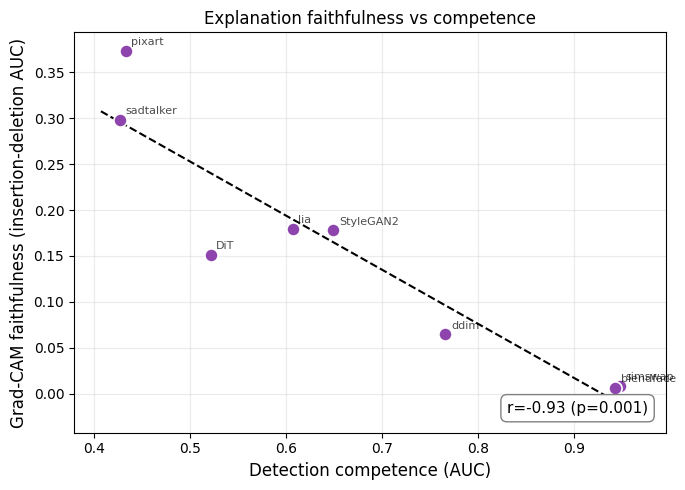

saved: /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/explanation_faithfulness_vs_competence.png
 m external/DeepfakeBench
A  figures/explanation_faithfulness_vs_competence.png
 M notebooks/NB06_effnet_df40.ipynb
 M notebooks/NB08_timeline_scoring.ipynb
 M notebooks/NB09_labelfree_competence.ipynb
AM notebooks/NB10_explanation_stability.ipynb
A  reports/calibration/explanation_faithfulness.csv
 M src/inference.py

>>> review, then commit with the coupling verdict


In [5]:
import pandas as pd, numpy as np, os
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
fa = pd.read_csv(f"{REPO}/reports/calibration/explanation_faithfulness.csv").dropna(subset=['AUC','faithfulness'])

if len(fa)>=4:
    fig,ax=plt.subplots(figsize=(7,5))
    ax.scatter(fa.AUC, fa.faithfulness, s=90, c="#8E44AD", edgecolor="white", linewidth=1.2, zorder=3)
    for _,r in fa.iterrows():
        ax.annotate(r['method'], (r['AUC'],r['faithfulness']), fontsize=8, alpha=0.7,
                    xytext=(4,4), textcoords='offset points')
    x,y=fa.AUC.values, fa.faithfulness.values
    b,a=np.polyfit(x,y,1); xs=np.linspace(x.min()-.02,x.max()+.02,100)
    ax.plot(xs,a+b*xs,"k--",lw=1.5)
    rr,pp=pearsonr(x,y)
    ax.annotate(f"r={rr:.2f} (p={pp:.3f})",xy=(.97,.05),xycoords="axes fraction",ha="right",
                fontsize=11,bbox=dict(boxstyle="round,pad=0.4",fc="white",ec="gray"))
    ax.set_xlabel("Detection competence (AUC)",fontsize=12)
    ax.set_ylabel("Grad-CAM faithfulness (insertion-deletion AUC)",fontsize=12)
    ax.set_title("Explanation faithfulness vs competence",fontsize=12)
    ax.grid(True,alpha=0.25); plt.tight_layout()
    out=f"{REPO}/figures/explanation_faithfulness_vs_competence.png"
    plt.savefig(out,dpi=300,bbox_inches="tight"); plt.show()
    print("saved:",out)

import subprocess
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add reports/calibration/explanation_faithfulness.csv figures/explanation_faithfulness_vs_competence.png notebooks/NB10_explanation_stability.ipynb", shell=True)
r=subprocess.run("git status --short",shell=True,capture_output=True,text=True)
print(r.stdout)
print(">>> review, then commit with the coupling verdict")

In [6]:
import pandas as pd, numpy as np, os, glob, zipfile, shutil
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT = "/content/drive/MyDrive/CDTS_Research/DF40"
LOCALCORE = f"{REPO}/data/df40_core/test"

# normalized faithfulness: control for starting score (saturation)
# Two saturation-robust metrics:
#  (1) deletion DROP fraction: (start_score - min_during_deletion) / start_score
#      -> what fraction of the score can the explanation destroy? (high=faithful, range-normalized)
#  (2) correlation between |importance| and actual score-change when that region is deleted
#      (a direct faithfulness measure independent of absolute score level)

def faithfulness_normalized(im_hwc, cam, steps=20):
    flat = cam.flatten(); order = np.argsort(-flat)
    n=len(order); chunk=n//steps; H,W=cam.shape
    blurred = cv2.GaussianBlur(im_hwc,(0,0),sigmaX=11)
    start = prob_fake_of(im_hwc)
    img_del = im_hwc.copy(); del_scores=[start]
    for s in range(steps):
        idx=order[s*chunk:(s+1)*chunk]; ys,xs=np.unravel_index(idx,(H,W))
        img_del[ys,xs,:]=blurred[ys,xs,:]; del_scores.append(prob_fake_of(img_del))
    del_scores=np.array(del_scores)
    # normalized deletion drop: fraction of starting score destroyed
    drop_frac = (start - del_scores.min())/(start+1e-6)
    # raw drop (absolute)
    abs_drop = start - del_scores.min()
    return start, drop_frac, abs_drop

# test on 2 high-competence + 2 low-competence generators
TEST = ["simswap","blendface","pixart","sadtalker"]
rows=[]
for method in TEST:
    sp=f"{REPO}/reports/scores/xceptionFS_df40_{method}.parquet"
    s=pd.read_parquet(sp); fakes=s[s.label==1]
    tl=pd.read_csv(f"{REPO}/reports/calibration/timeline_df40_xceptionFS.csv")
    auc=float(tl[tl.method==method].AUC.iloc[0])
    zp=None
    for c in [f"{LOCALCORE}/{method}.zip",f"{SHORTCUT}/{method}.zip"]:
        if os.path.exists(c) and os.path.getsize(c)>1e6: zp=c;break
    if not zp: continue
    fdir=f"/content/xain_{method}"; os.makedirs(fdir,exist_ok=True)
    with zipfile.ZipFile(zp) as z: z.extractall(fdir)
    fidx={"/".join(fp.split("/")[-2:]):fp for fp in glob.glob(f"{fdir}/**/*.png",recursive=True)}
    starts=[];dropfracs=[];absdrops=[]
    done=0
    for _,r in fakes.sample(min(len(fakes),120),random_state=1).iterrows():
        fp=fidx.get("/".join(str(r['frame_path']).split("/")[-2:]))
        if not fp or not os.path.exists(fp): continue
        try:
            im=load_img(fp); cam,_=grad_cam(im)
            st,df_,ad=faithfulness_normalized(im,cam,steps=20)
            starts.append(st);dropfracs.append(df_);absdrops.append(ad);done+=1
            if done>=50:break
        except: continue
    shutil.rmtree(fdir,ignore_errors=True)
    rows.append({"method":method,"AUC":auc,"mean_start_score":np.mean(starts),
                 "norm_drop_frac":np.mean(dropfracs),"abs_drop":np.mean(absdrops),"n":done})
    print(f"{method}: AUC={auc:.3f} start_score={np.mean(starts):.3f} norm_drop={np.mean(dropfracs):.3f} abs_drop={np.mean(absdrops):.3f}")

nf=pd.DataFrame(rows)
print("\n=== saturation check ===")
print(nf.to_string(index=False))
from scipy.stats import pearsonr
if len(nf)>=4:
    r1,p1=pearsonr(nf.AUC,nf.norm_drop_frac)
    r2,p2=pearsonr(nf.AUC,nf.mean_start_score)
    print(f"\nNORMALIZED faithfulness (drop fraction) vs AUC: r={r1:.3f} (p={p1:.3f})")
    print(f"start_score vs AUC: r={r2:.3f} (p={p2:.3f})  <- if very high, confirms saturation confound")
    print("\nIf norm_drop_frac vs AUC is still strong -> real coupling. If it flattens -> was saturation.")

simswap: AUC=0.948 start_score=0.957 norm_drop=0.112 abs_drop=0.083
blendface: AUC=0.943 start_score=0.999 norm_drop=0.052 abs_drop=0.052
pixart: AUC=0.433 start_score=0.292 norm_drop=0.216 abs_drop=0.044
sadtalker: AUC=0.427 start_score=0.319 norm_drop=0.179 abs_drop=0.033

=== saturation check ===
   method    AUC  mean_start_score  norm_drop_frac  abs_drop  n
  simswap 0.9478          0.957246        0.112254  0.083210 50
blendface 0.9429          0.998817        0.052137  0.051887 50
   pixart 0.4329          0.292085        0.216083  0.044106 50
sadtalker 0.4270          0.318818        0.178601  0.032680 50

NORMALIZED faithfulness (drop fraction) vs AUC: r=-0.913 (p=0.087)
start_score vs AUC: r=0.998 (p=0.002)  <- if very high, confirms saturation confound

If norm_drop_frac vs AUC is still strong -> real coupling. If it flattens -> was saturation.
